In [2]:
# Step 1: Install Kaggle library
!pip install kaggle


In [3]:
# Step 2: Prepare Kaggle API key inside Google Colab

import os
import shutil

# Create Kaggle hidden folder
os.makedirs("/root/.kaggle", exist_ok=True)

# Copy kaggle.json file to the required Kaggle folder
shutil.copy("/content/kaggle.json", "/root/.kaggle/kaggle.json")

# Give proper permission to the Kaggle API file
os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle API key is ready.")

Kaggle API key is ready.


In [4]:
# Step 3: Download Chest X-ray Pneumonia dataset from Kaggle

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content --unzip

print("Dataset downloaded successfully.")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:15<00:00, 159MB/s]

Dataset downloaded successfully.


In [16]:
import os

dataset_path = "/content/chest_xray_pneumonia/chest_xray"

# Print the main folders inside the dataset
print("Main folders inside dataset:")
print(os.listdir(dataset_path))

# Define train, validation, and test paths
train_dir = os.path.join(dataset_path, "train")
val_dir = os.path.join(dataset_path, "val")
test_dir = os.path.join(dataset_path, "test")

print("\nTrain path:", train_dir)
print("Validation path:", val_dir)
print("Test path:", test_dir)

# Print the classes inside each folder
print("\nTrain classes:", os.listdir(train_dir))
print("Validation classes:", os.listdir(val_dir))
print("Test classes:", os.listdir(test_dir))

Main folders inside dataset:


FileNotFoundError: [Errno 2] No such file or directory: '/content/chest_xray_pneumonia/chest_xray'

In [5]:
# Step 4A: Find the real dataset path

import os

for root, dirs, files in os.walk("/content"):
    if "train" in dirs and "test" in dirs and "val" in dirs:
        print("FOUND DATASET PATH:")
        print(root)

In [6]:
# Step 4B: Show the folder structure inside /content

import os

def show_folder_tree(start_path, max_depth=3):
    for root, dirs, files in os.walk(start_path):
        depth = root.replace(start_path, "").count(os.sep)

        if depth < max_depth:
            indent = "  " * depth
            print(f"{indent}{os.path.basename(root)}/")

            for folder in dirs[:10]:
                print(f"{indent}  {folder}/")

show_folder_tree("/content", max_depth=3)

content/
  .config/
  sample_data/
  .config/
    configurations/
    logs/
    configurations/
    logs/
      2026.05.18/
  sample_data/


In [7]:
# Step 4C: Re-download the Chest X-ray Pneumonia dataset

!pip install kaggle -q

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content --unzip

print("Dataset downloaded successfully.")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [01:02<00:00, 39.3MB/s]

Dataset downloaded successfully.


In [8]:
# Step 4D: Check what files and folders exist inside /content

import os

print("Files and folders inside /content:")
print(os.listdir("/content"))

Files and folders inside /content:
['.config', 'chest_xray', 'sample_data']


In [9]:
# Step 5: Find the correct dataset path

import os

main_path = "/content/chest_xray"

print("Inside /content/chest_xray:")
print(os.listdir(main_path))

print("\nChecking possible dataset paths:")

possible_paths = [
    "/content/chest_xray",
    "/content/chest_xray/chest_xray"
]

for path in possible_paths:
    if os.path.exists(path):
        print("\nPath exists:", path)
        print("Folders inside it:", os.listdir(path))

        if all(folder in os.listdir(path) for folder in ["train", "test", "val"]):
            print("✅ Correct dataset path found:")
            print(path)

Inside /content/chest_xray:
['chest_xray', 'val', 'train', 'test', '__MACOSX']

Checking possible dataset paths:

Path exists: /content/chest_xray
Folders inside it: ['chest_xray', 'val', 'train', 'test', '__MACOSX']
✅ Correct dataset path found:
/content/chest_xray

Path exists: /content/chest_xray/chest_xray
Folders inside it: ['val', 'train', '.DS_Store', 'test']
✅ Correct dataset path found:
/content/chest_xray/chest_xray


In [10]:
# Step 6: Set final dataset paths and check classes

import os

# Final dataset path
dataset_path = "/content/chest_xray"

# Define train, validation, and test folders
train_dir = os.path.join(dataset_path, "train")
val_dir = os.path.join(dataset_path, "val")
test_dir = os.path.join(dataset_path, "test")

# Print paths
print("Training folder:", train_dir)
print("Validation folder:", val_dir)
print("Testing folder:", test_dir)

# Print class folders
print("\nTraining classes:", os.listdir(train_dir))
print("Validation classes:", os.listdir(val_dir))
print("Testing classes:", os.listdir(test_dir))

# Count images in each class
for folder_name, folder_path in [("Train", train_dir), ("Validation", val_dir), ("Test", test_dir)]:
    print(f"\n{folder_name} image count:")

    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)

        if os.path.isdir(class_path):
            image_count = len(os.listdir(class_path))
            print(f"{class_name}: {image_count} images")

Training folder: /content/chest_xray/train
Validation folder: /content/chest_xray/val
Testing folder: /content/chest_xray/test

Training classes: ['PNEUMONIA', 'NORMAL']
Validation classes: ['PNEUMONIA', 'NORMAL']
Testing classes: ['PNEUMONIA', 'NORMAL']

Train image count:
PNEUMONIA: 3875 images
NORMAL: 1341 images

Validation image count:
PNEUMONIA: 8 images
NORMAL: 8 images

Test image count:
PNEUMONIA: 390 images
NORMAL: 234 images


In [11]:
# Step 7: Load image datasets using TensorFlow

import tensorflow as tf

# Image settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# We define the class order manually:
# NORMAL = 0
# PNEUMONIA = 1
class_names = ["NORMAL", "PNEUMONIA"]

# Load training data from train folder and split 80% for training
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="binary",
    class_names=class_names,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load 20% of train folder as validation data
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="binary",
    class_names=class_names,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load test data from test folder
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="binary",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Class names:", class_names)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Datasets loaded successfully.")

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.
Class names: ['NORMAL', 'PNEUMONIA']
Image size: (224, 224)
Batch size: 32
Datasets loaded successfully.


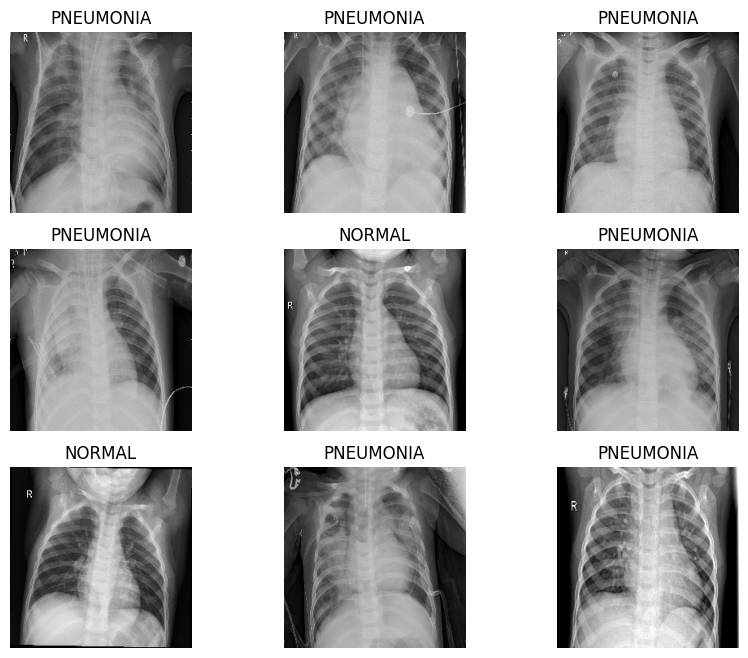

In [12]:
# Step 8: Display sample chest X-ray images from the training dataset

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Take one batch of images from the training dataset
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        # Show image
        plt.imshow(images[i].numpy().astype("uint8"))

        # Convert label from 0/1 to class name
        label_index = int(labels[i].numpy()[0])
        plt.title(class_names[label_index])

        plt.axis("off")

plt.show()

In [13]:
# Step 9: Improve dataset performance and define data augmentation

from tensorflow.keras import layers

# Improve loading speed during training
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# Data augmentation layer to reduce overfitting
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10)
])

print("Dataset performance optimization completed.")
print("Data augmentation layer created successfully.")

Dataset performance optimization completed.
Data augmentation layer created successfully.


In [14]:
# Step 10: Build the Custom CNN model

from tensorflow.keras import models, layers

# Custom CNN architecture for binary image classification
custom_cnn = models.Sequential([
    # Input layer: images are resized to 224x224 with 3 color channels
    layers.Input(shape=(224, 224, 3)),

    # Data augmentation helps reduce overfitting
    data_augmentation,

    # Normalize pixel values from 0-255 to 0-1
    layers.Rescaling(1./255),

    # First convolution block
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Third convolution block
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Flatten feature maps into one vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Dropout reduces overfitting
    layers.Dropout(0.5),

    # Output layer: sigmoid because this is binary classification
    layers.Dense(1, activation="sigmoid")
])

# Compile the model
custom_cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Show model architecture
custom_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [1]:
# Step 11: Check if GPU is available

import tensorflow as tf

gpu_devices = tf.config.list_physical_devices("GPU")

if gpu_devices:
    print("GPU is available.")
    print(gpu_devices)
else:
    print("GPU is NOT available.")
    print("Please enable GPU from Runtime > Change runtime type > T4 GPU.")

GPU is available.
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Step 12: Check if important variables still exist after enabling GPU

needed_variables = [
    "train_dir",
    "test_dir",
    "train_ds",
    "val_ds",
    "test_ds",
    "data_augmentation",
    "custom_cnn"
]

for var in needed_variables:
    if var in globals():
        print(var, "exists")
    else:
        print(var, "MISSING")

train_dir MISSING
test_dir MISSING
train_ds MISSING
val_ds MISSING
test_ds MISSING
data_augmentation MISSING
custom_cnn MISSING


In [3]:
# Step 12A: Check if dataset files still exist after enabling GPU

import os

print("Files and folders inside /content:")
print(os.listdir("/content"))

if os.path.exists("/content/chest_xray/train"):
    print("\nDataset still exists.")
    print("Train folder found:", "/content/chest_xray/train")
else:
    print("\nDataset is missing.")
    print("We need to re-download it or upload it again.")

Files and folders inside /content:
['.config', 'sample_data']

Dataset is missing.
We need to re-download it or upload it again.


In [4]:
# Step 12B: Prepare Kaggle API again and re-download dataset after GPU restart

import os
import shutil

# Install Kaggle library
!pip install kaggle -q

# Create Kaggle folder
os.makedirs("/root/.kaggle", exist_ok=True)

# Copy kaggle.json to the required location
shutil.copy("/content/kaggle.json", "/root/.kaggle/kaggle.json")

# Set permission
os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle API key is ready.")

# Download and unzip dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content --unzip

print("Dataset downloaded successfully.")

Kaggle API key is ready.
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:20<00:00, 117MB/s]

Dataset downloaded successfully.


In [5]:
# Step 13: Rebuild all required variables after GPU restart

import os
import tensorflow as tf
from tensorflow.keras import layers, models

# -----------------------------
# 1. Dataset paths
# -----------------------------
dataset_path = "/content/chest_xray"

train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")

print("Training folder:", train_dir)
print("Testing folder:", test_dir)

# -----------------------------
# 2. Image settings
# -----------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Class order:
# NORMAL = 0
# PNEUMONIA = 1
class_names = ["NORMAL", "PNEUMONIA"]

# -----------------------------
# 3. Load datasets
# -----------------------------
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="binary",
    class_names=class_names,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="binary",
    class_names=class_names,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="binary",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# -----------------------------
# 4. Improve loading speed
# -----------------------------
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# -----------------------------
# 5. Data augmentation
# -----------------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10)
])

# -----------------------------
# 6. Build Custom CNN model
# -----------------------------
custom_cnn = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

custom_cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\nAll variables were rebuilt successfully.")
print("Custom CNN is ready for training.")

Training folder: /content/chest_xray/train
Testing folder: /content/chest_xray/test
Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.

All variables were rebuilt successfully.
Custom CNN is ready for training.


In [6]:
# Step 14: Train the Custom CNN model

from tensorflow.keras.callbacks import EarlyStopping

# Early stopping stops training if validation loss does not improve
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train the Custom CNN model
history_cnn = custom_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

print("Custom CNN training completed successfully.")

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 38s 231ms/step - accuracy: 0.7441 - loss: 0.5496 - val_accuracy: 0.8907 - val_loss: 0.2702
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 239ms/step - accuracy: 0.8299 - loss: 0.3481 - val_accuracy: 0.9118 - val_loss: 0.2125
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 30s 231ms/step - accuracy: 0.8792 - loss: 0.2941 - val_accuracy: 0.8974 - val_loss: 0.2112
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 239ms/step - accuracy: 0.9085 - loss: 0.2407 - val_accuracy: 0.9310 - val_loss: 0.1671
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 268ms/step - accuracy: 0.9166 - loss: 0.2189 - val_accuracy: 0.9463 - val_loss: 0.1524
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 240ms/step - accuracy: 0.9295 - loss: 0.1968 - val_accuracy: 0.9559 - val_loss: 0.1088
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 30s 230ms/step - accuracy: 0.9377 - loss: 0.1772 - val_accuracy: 0.9156 - val_loss: 0.1867
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 46s 268ms/step - accuracy: 0.9312 - loss: 0

In [7]:
# Step 15: Evaluate the Custom CNN model on the test dataset

import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# Lists to store true labels and predicted labels
y_true = []
y_pred = []

# Predict labels for all test images
for images, labels in test_ds:
    predictions = custom_cnn.predict(images, verbose=0)

    # Convert probabilities to binary labels
    predicted_labels = (predictions > 0.5).astype("int32")

    y_true.extend(labels.numpy().astype("int32").flatten())
    y_pred.extend(predicted_labels.flatten())

# Calculate evaluation metrics
cnn_accuracy = accuracy_score(y_true, y_pred)
cnn_precision = precision_score(y_true, y_pred)
cnn_recall = recall_score(y_true, y_pred)
cnn_f1 = f1_score(y_true, y_pred)

print("Custom CNN Test Evaluation Results")
print("----------------------------------")
print("Accuracy :", round(cnn_accuracy, 4))
print("Precision:", round(cnn_precision, 4))
print("Recall   :", round(cnn_recall, 4))
print("F1-score :", round(cnn_f1, 4))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Custom CNN Test Evaluation Results
----------------------------------
Accuracy : 0.8253
Precision: 0.7909
Recall   : 0.9795
F1-score : 0.8751

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.94      0.57      0.71       234
   PNEUMONIA       0.79      0.98      0.88       390

    accuracy                           0.83       624
   macro avg       0.87      0.77      0.79       624
weighted avg       0.85      0.83      0.81       624

Confusion Matrix:
[[133 101]
 [  8 382]]


In [9]:
# Step 16: Build MobileNetV2 transfer learning model

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Load MobileNetV2 without the final classification layer
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the base model so pretrained features are not changed during initial training
base_model.trainable = False

# Build the transfer learning model
inputs = layers.Input(shape=(224, 224, 3))

# Apply data augmentation
x = data_augmentation(inputs)

# Preprocess images according to MobileNetV2 requirements
x = preprocess_input(x)

# Extract features using MobileNetV2
x = base_model(x, training=False)

# Convert feature maps into one vector
x = layers.GlobalAveragePooling2D()(x)

# Dropout helps reduce overfitting
x = layers.Dropout(0.3)(x)

# Dense layer for classification
x = layers.Dense(128, activation="relu")(x)

# Output layer: sigmoid for binary classification
outputs = layers.Dense(1, activation="sigmoid")(x)

# Create final model
mobilenet_model = tf.keras.Model(inputs, outputs)

# Compile the model
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Show model architecture
mobilenet_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
# Step 17: Train the MobileNetV2 transfer learning model

from tensorflow.keras.callbacks import EarlyStopping

# Stop training if validation loss does not improve
early_stop_mobilenet = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train MobileNetV2 model
history_mobilenet = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop_mobilenet]
)

print("MobileNetV2 training completed successfully.")

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 41s 268ms/step - accuracy: 0.8423 - loss: 0.3507 - val_accuracy: 0.9291 - val_loss: 0.2082
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 37s 242ms/step - accuracy: 0.9197 - loss: 0.2086 - val_accuracy: 0.9338 - val_loss: 0.1744
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 40s 238ms/step - accuracy: 0.9363 - loss: 0.1636 - val_accuracy: 0.9473 - val_loss: 0.1534
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 33s 251ms/step - accuracy: 0.9324 - loss: 0.1660 - val_accuracy: 0.9530 - val_loss: 0.1423
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 40s 246ms/step - accuracy: 0.9418 - loss: 0.1529 - val_accuracy: 0.9358 - val_loss: 0.1743
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 40s 235ms/step - accuracy: 0.9480 - loss: 0.1334 - val_accuracy: 0.9434 - val_loss: 0.1520
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 235ms/step - accuracy: 0.9473 - loss: 0.1410 - val_accuracy: 0.9463 - val_loss: 0.1506
MobileNetV2 training completed successfully.


In [11]:
# Step 18: Evaluate the MobileNetV2 model on the test dataset

import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# Lists to store true labels and predicted labels
y_true_mobilenet = []
y_pred_mobilenet = []

# Predict labels for all test images
for images, labels in test_ds:
    predictions = mobilenet_model.predict(images, verbose=0)

    # Convert probabilities to binary labels
    predicted_labels = (predictions > 0.5).astype("int32")

    y_true_mobilenet.extend(labels.numpy().astype("int32").flatten())
    y_pred_mobilenet.extend(predicted_labels.flatten())

# Calculate evaluation metrics
mobilenet_accuracy = accuracy_score(y_true_mobilenet, y_pred_mobilenet)
mobilenet_precision = precision_score(y_true_mobilenet, y_pred_mobilenet)
mobilenet_recall = recall_score(y_true_mobilenet, y_pred_mobilenet)
mobilenet_f1 = f1_score(y_true_mobilenet, y_pred_mobilenet)

print("MobileNetV2 Test Evaluation Results")
print("-----------------------------------")
print("Accuracy :", round(mobilenet_accuracy, 4))
print("Precision:", round(mobilenet_precision, 4))
print("Recall   :", round(mobilenet_recall, 4))
print("F1-score :", round(mobilenet_f1, 4))

print("\nClassification Report:")
print(classification_report(y_true_mobilenet, y_pred_mobilenet, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(y_true_mobilenet, y_pred_mobilenet))

MobileNetV2 Test Evaluation Results
-----------------------------------
Accuracy : 0.7981
Precision: 0.764
Recall   : 0.9795
F1-score : 0.8584

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.94      0.50      0.65       234
   PNEUMONIA       0.76      0.98      0.86       390

    accuracy                           0.80       624
   macro avg       0.85      0.74      0.75       624
weighted avg       0.83      0.80      0.78       624

Confusion Matrix:
[[116 118]
 [  8 382]]


In [12]:
# Step 19: Create final comparison table between Custom CNN and MobileNetV2

import pandas as pd

# Create a comparison table using the real test results
results_df = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2"],
    "Accuracy": [cnn_accuracy, mobilenet_accuracy],
    "Precision": [cnn_precision, mobilenet_precision],
    "Recall": [cnn_recall, mobilenet_recall],
    "F1-score": [cnn_f1, mobilenet_f1]
})

# Round results to 4 decimal places
results_df = results_df.round(4)

print("Final Model Performance Comparison")
print("----------------------------------")
print(results_df)

Final Model Performance Comparison
----------------------------------
         Model  Accuracy  Precision  Recall  F1-score
0   Custom CNN    0.8253     0.7909  0.9795    0.8751
1  MobileNetV2    0.7981     0.7640  0.9795    0.8584


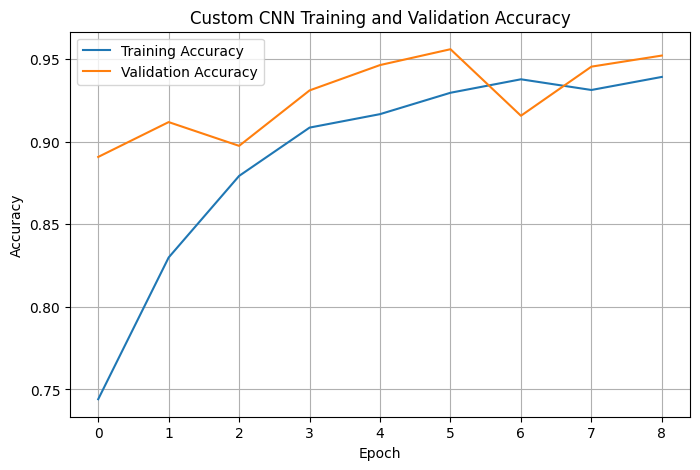

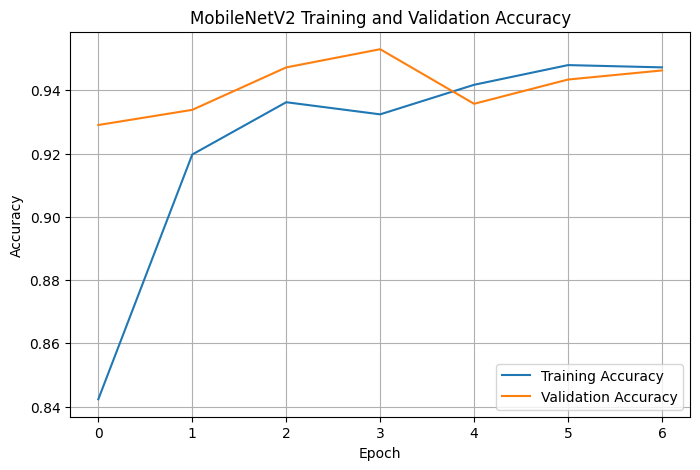

In [13]:
# Step 20: Plot training and validation accuracy for both models

import matplotlib.pyplot as plt

# Plot Custom CNN accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history["accuracy"], label="Training Accuracy")
plt.plot(history_cnn.history["val_accuracy"], label="Validation Accuracy")
plt.title("Custom CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot MobileNetV2 accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_mobilenet.history["accuracy"], label="Training Accuracy")
plt.plot(history_mobilenet.history["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNetV2 Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()